In [5]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [8]:
# 2. LOAD DATA

df = pd.read_csv("SampleSuperstore.csv", encoding='latin1')

In [9]:
# 3. BASIC EDA

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe:")
print(df.describe())

Shape: (9994, 21)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64

In [10]:
# 4. CLEANING

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64


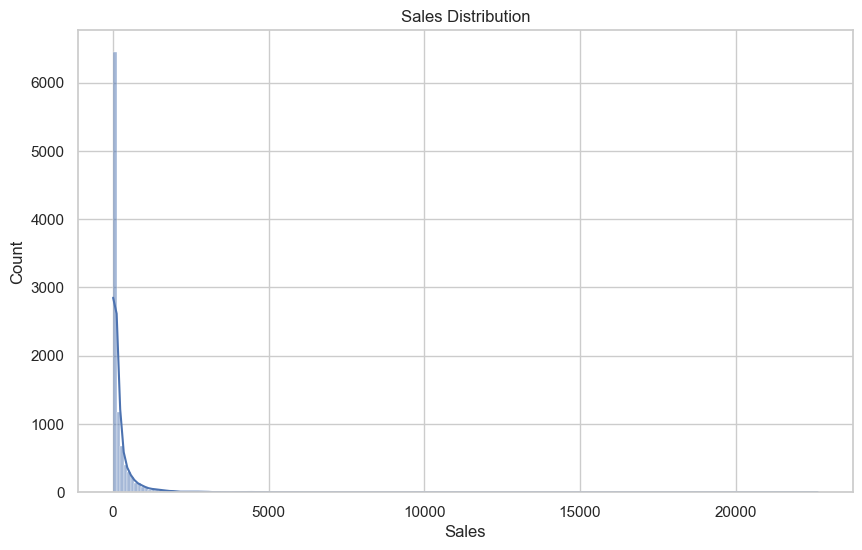

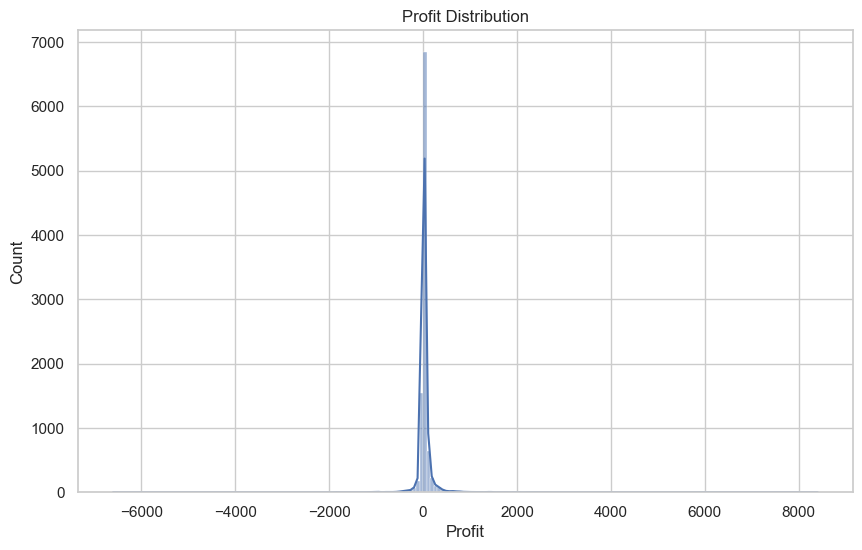

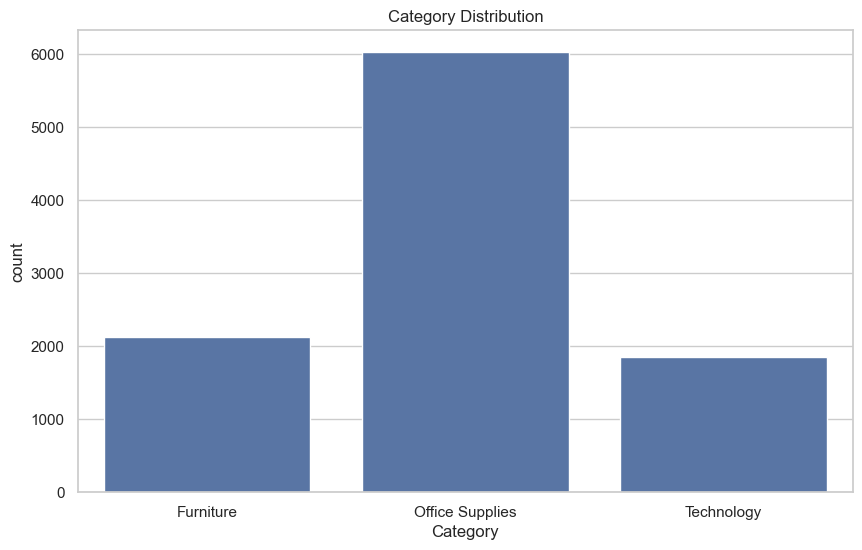

In [11]:
# 5. UNIVARIATE ANALYSIS

# 1. Sales Distribution
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

# 2. Profit Distribution
sns.histplot(df['Profit'], kde=True)
plt.title("Profit Distribution")
plt.show()

# 3. Category Count
sns.countplot(x='Category', data=df)
plt.title("Category Distribution")
plt.show()


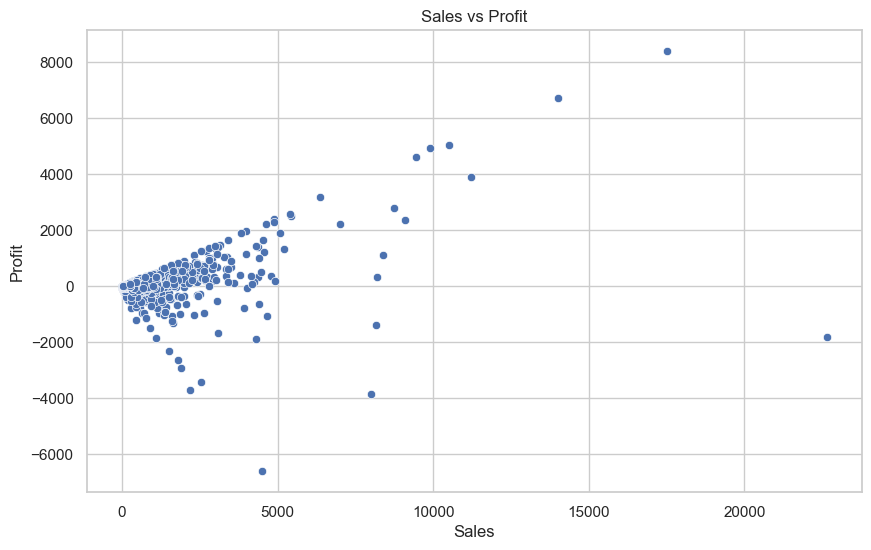

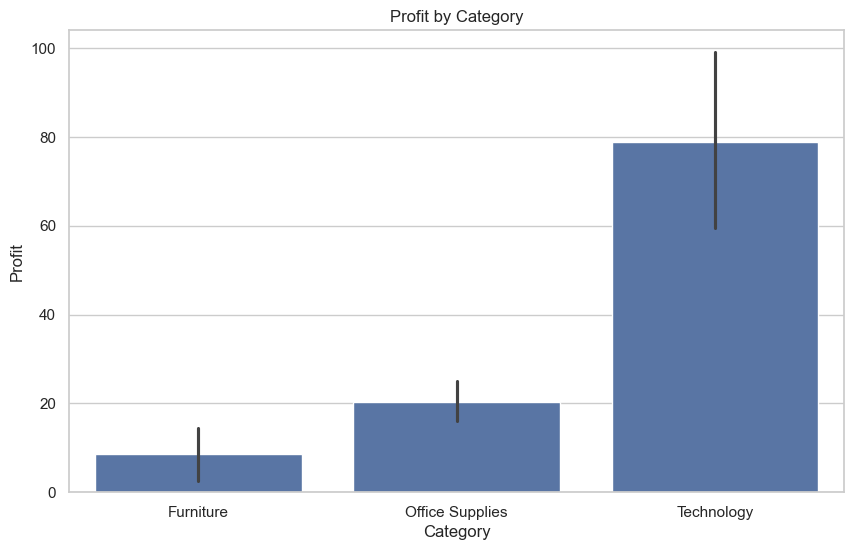

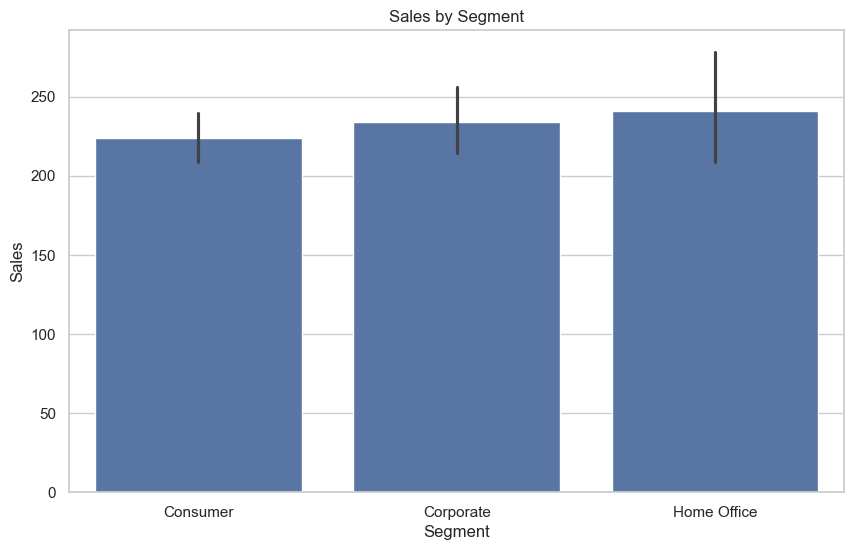

In [12]:
# 6. BIVARIATE ANALYSIS

# 4. Sales vs Profit
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

# 5. Profit by Category
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

# 6. Sales by Segment
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Segment")
plt.show()


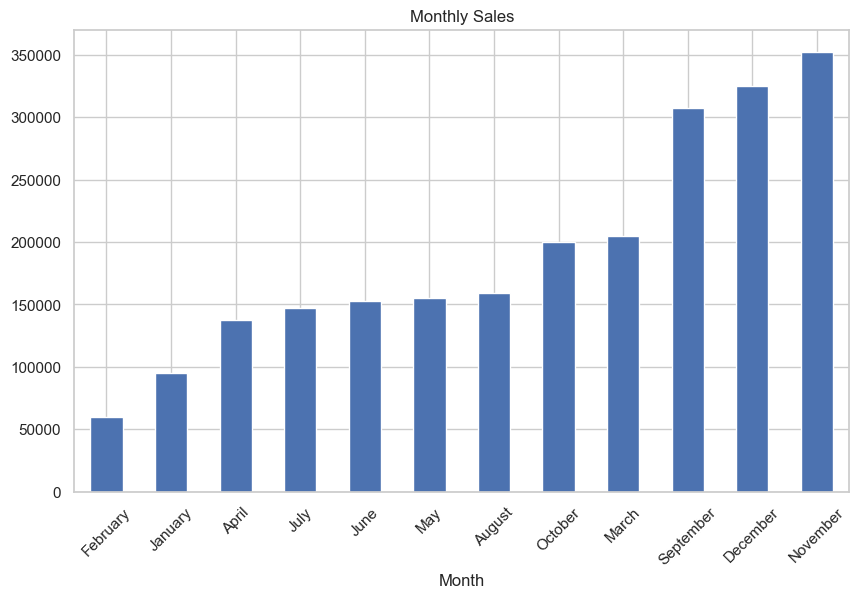

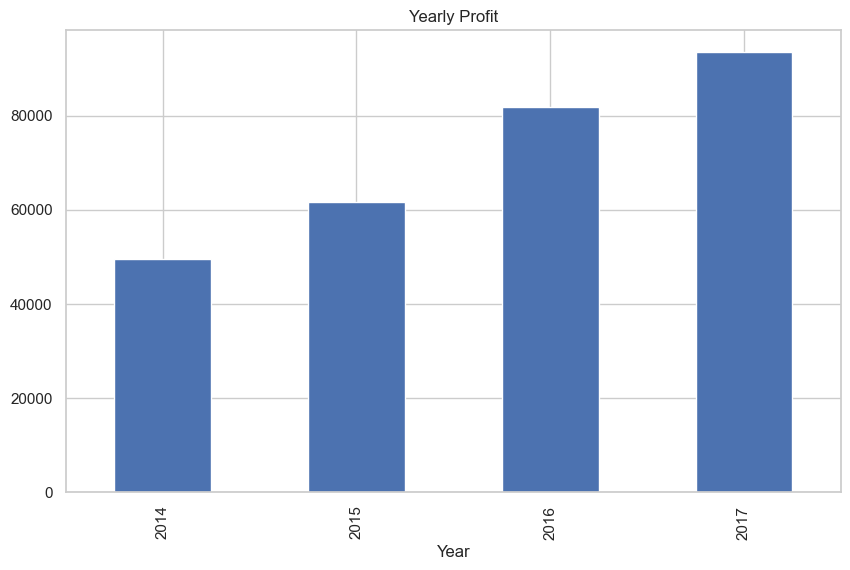

In [14]:
# 7. TIME SERIES

# 7. Monthly Sales
monthly_sales = df.groupby('Month')['Sales'].sum().sort_values()
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales")
plt.xticks(rotation=45)
plt.show()

# 8. Yearly Profit
yearly_profit = df.groupby('Year')['Profit'].sum()
yearly_profit.plot(kind='bar')
plt.title("Yearly Profit")
plt.show()


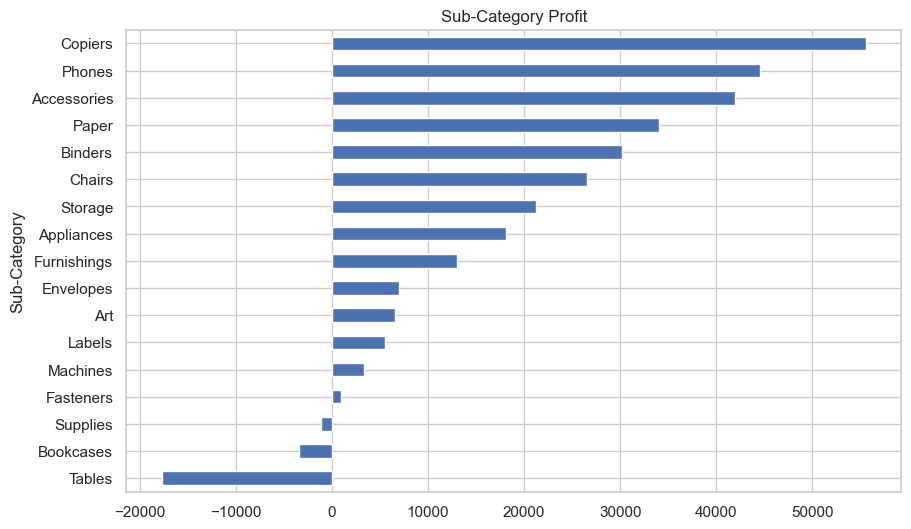

In [15]:
# 8. CATEGORY ANALYSIS

# 9. Sub-category Profit
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit.plot(kind='barh')
plt.title("Sub-Category Profit")
plt.show()

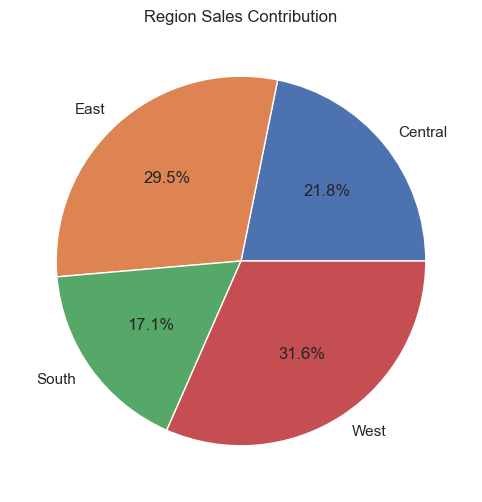

In [16]:
# 9. REGION ANALYSIS

# Region Sales
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Region Sales Contribution")
plt.ylabel("")
plt.show()


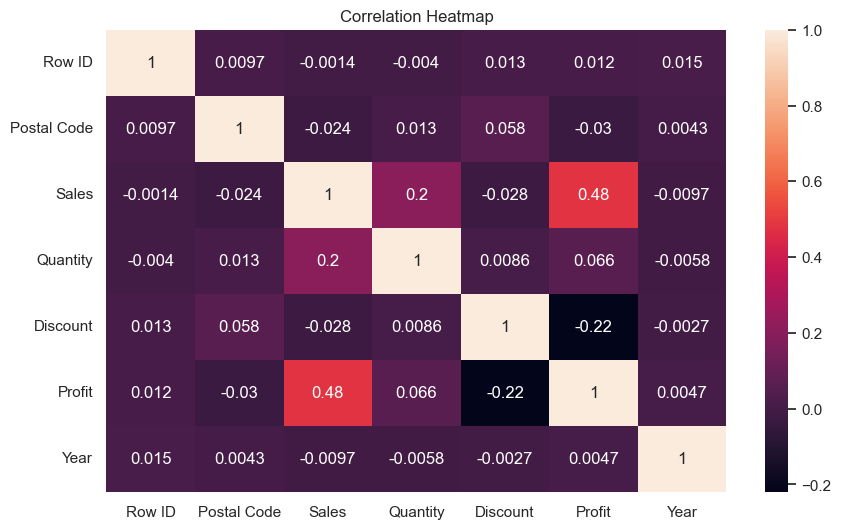

In [17]:
# 10.CORRELATION

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()